# scVI (State of the Art ) Results

In [126]:
import scanpy as sc
import scvi
import numpy as np

adata_ref = sc.read_h5ad("D:/ankita/Mouse adipose/mouse_adipose .h5ad")   # must have cell_type
adata_query = sc.read_h5ad("D:/ankita/Mouse adipose/xenium_final (2).h5ad")     # your dataset

# Ensure gene names match
adata_ref.var_names_make_unique()
adata_query.var_names_make_unique()



In [127]:
from scvi.model import SCVI

In [128]:
adata_ref.X = adata_ref.raw.X.copy()

In [129]:
adata_ref.var_names = adata_ref.var["feature_name"]
adata_ref.var_names_make_unique()

In [130]:
adata_ref.var_names

Index(['0610005C13Rik', '0610006L08Rik', 'Trappc2b', '0610009E02Rik', 'Dele1',
       'Sanbr', '0610010K14Rik', '0610012D04Rik', 'Ncbp2as2', '0610025J13Rik',
       ...
       'Gm39459', 'Gm45843', 'Prm2', 'Wfdc16', 'Zfp648', 'Cmtm2a', 'Gm15156',
       'Rnase2b', 'Gm12343', 'Gm28231'],
      dtype='object', name='feature_name', length=24551)

In [131]:
adata_query.var_names

Index(['A1cf', 'A2m', 'Aatf', 'Abca1', 'Abca13', 'Abca3', 'Abca4', 'Abca7',
       'Abca8a', 'Abca8b',
       ...
       'Zp1', 'Zp3', 'Zscan2', 'Zscan21', 'Zswim5', 'Zswim9', 'Zup1', 'Zyx',
       'Zzef1', 'a'],
      dtype='object', length=5006)

In [132]:
# Keep only shared genes
common_genes = adata_ref.var_names.intersection(adata_query.var_names)
adata_ref = adata_ref[:, common_genes].copy()
adata_query = adata_query[:, common_genes].copy()

adata_ref.obs["batch"] = "ref"
adata_query.obs["batch"] = "query"


In [133]:
import numpy as np

# Access only the non-zero values
data = adata_ref.X.data

print("Has decimals:", np.any(data % 1 != 0))
print("Min:", data.min())
print("Max:", data.max())
print("NaNs:", np.isnan(data).sum())
print("Infs:", np.isinf(data).sum())
print("dtype:", data.dtype)

Has decimals: False
Min: 1.0
Max: 2326.0
NaNs: 0
Infs: 0
dtype: float32


In [134]:
adata_ref

AnnData object with n_obs × n_vars = 70547 × 4725
    obs: 'biosample_id', 'assay_ontology_term_id', 'donor_id', 'mouse_strain_label', 'tissue_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'organism_weight', 'organism_weight_unit', 'disease_ontology_term_id', 'diet_type', 'diet_schedule', 'n_umis', 'n_genes', 'spliced_percent', 'unspliced_percent', 'splicing_ratio', 'mitochondrial_percent', 'ribosomal_protein_percent', 'sct_n_umis', 'sct_n_genes', 'cell_cycle_s_score', 'cell_cycle_g2m_score', 'cell_cycle_phase', 'author_cell_type', 'author_cell_type_subcluster', 'cell_type_ontology_term_id', 'is_primary_data', 'suspension_type', 'self_reported_ethnicity_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'batch'
    var: 'ensembl_version', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
 

In [135]:

# Ensure label column exists in reference
adata_ref.obs["cell_type"] = adata_ref.obs["cell_type"].astype("category")

# For query, create dummy labels
adata_query.obs["cell_type"] = "Unknown"

adata = sc.concat([adata_ref, adata_query])

adata.obs["cell_type"] = adata.obs["cell_type"].astype("category")



C:\Users\ankit\AppData\Local\Temp\ipykernel_38492\2173078968.py:7: UserWarning: Only some AnnData objects have `.raw` attribute, not concatenating `.raw` attributes.
  adata = sc.concat([adata_ref, adata_query])


In [136]:
scvi.model.SCVI.setup_anndata(
    adata,
    batch_key="batch",
    labels_key="cell_type"
)

scvi_model = scvi.model.SCVI(adata)
scvi_model.train()



GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\ankit\anaconda3\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\ankit\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training:   0%|          | 0/99 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=99` reached.


In [137]:
scvi_model.save("scvi_model/", overwrite=True)

In [138]:
# Get latent representation
adata.obsm["X_scVI"] = scvi_model.get_latent_representation()




In [140]:

sc.pp.neighbors(adata, use_rep="X_scVI")
# sc.tl.umap(adata)


In [141]:
scanvi_model = scvi.model.SCANVI.from_scvi_model(
    scvi_model,
    labels_key="cell_type",
    unlabeled_category="Unknown"
)

scanvi_model.train()




INFO     Training for 10 epochs.                                                                                   


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
C:\Users\ankit\anaconda3\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\ankit\anaconda3\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Training:   0%|          | 0/10 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


In [142]:
adata.obs["batch"].unique()

array(['ref', 'query'], dtype=object)

In [143]:
adata.obs["predicted_cell_type"] = scanvi_model.predict(adata)



In [144]:
adata_query_final = adata[adata.obs["batch"] == "query"].copy()

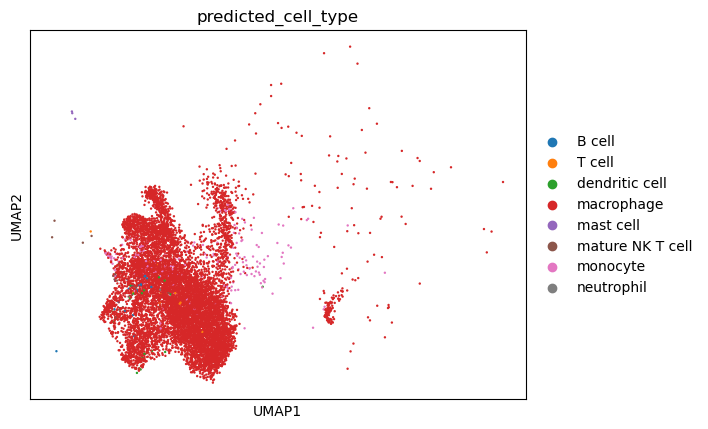

In [145]:
sc.pl.umap(adata_query_final,color='predicted_cell_type')

In [146]:
import matplotlib.pyplot as plt
fig=sc.pl.umap(adata_query_final,color='predicted_cell_type',show=False,return_fig=True)
fig.savefig(
    "scVI.pdf",
    bbox_inches="tight"
)

plt.close(fig)

In [151]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

score = silhouette_score(adata_query_final.obsm["X_scVI"],adata_query_final.obs["predicted_cell_type"])
print("Silhouette Score for clustering:", score)
X =adata_query_final.obsm["X_scVI"]
labels = adata_query_final.obs["predicted_cell_type"].astype(str)

chi_score = calinski_harabasz_score(X, labels)
dbi_score = davies_bouldin_score(X, labels)

print("Calinski-Harabasz Index:", chi_score)
print("Davies-Bouldin Index:", dbi_score)

Silhouette Score for clustering: -0.1390480101108551
Calinski-Harabasz Index: 24.932270050048828
Davies-Bouldin Index: 2.1344542566286604


In [152]:
adata_query_final

AnnData object with n_obs × n_vars = 10124 × 4725
    obs: 'cell_type', 'batch', '_scvi_batch', '_scvi_labels', 'predicted_cell_type'
    uns: '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'predicted_cell_type_colors'
    obsm: 'X_umap', 'X_scVI'
    obsp: 'distances', 'connectivities'